<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# TP3 - Detección del logotipo de Coca-Cola mediante Template Matching

**Materia:** Visión por Computadora I

**Profesor:** Ing. Maxim Dorogov

**Alumnos:** <br>
Juan Sebastián Bonals - jsbonals@gmail.com  <br>
Federico Santiago Fontanari - federicofontanari@gmail.com  <br>
Jose Andres Montes de Oca - amontesdeoca1982@gmail.com  <br>

**Objetivo:** encontrar el logotipo Coca Cola dentro de las imágenes en `images/`, a partir del template `template/pattern.png`.

1. Obtener una detección del logo en cada imagen, sin falsos positivos.
2. Plantear y validar un algoritmo para detecciones múltiples en `coca_multi.png`, usando el mismo template.
3. Generalizar el algoritmo de detección múltiple a todas las imágenes.

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import glob
import os

%matplotlib inline

In [ ]:
import os

REPO_URL = 'https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/vision_computadora_I.git'
REPO_DIR = 'vision_computadora_I'

if not os.path.exists(REPO_DIR):
    !git clone -q {REPO_URL}

if not os.path.exists('images'):
    os.symlink(f'{REPO_DIR}/Material_TPs/TP3/images', 'images')
    os.symlink(f'{REPO_DIR}/Material_TPs/TP3/template', 'template')

IMAGES_DIR = 'images'
TEMPLATE_PATH = 'template/pattern.png'

## Enfoque general

Antes de elegir un método, miramos el template y las imágenes donde hay que encontrar el logo.

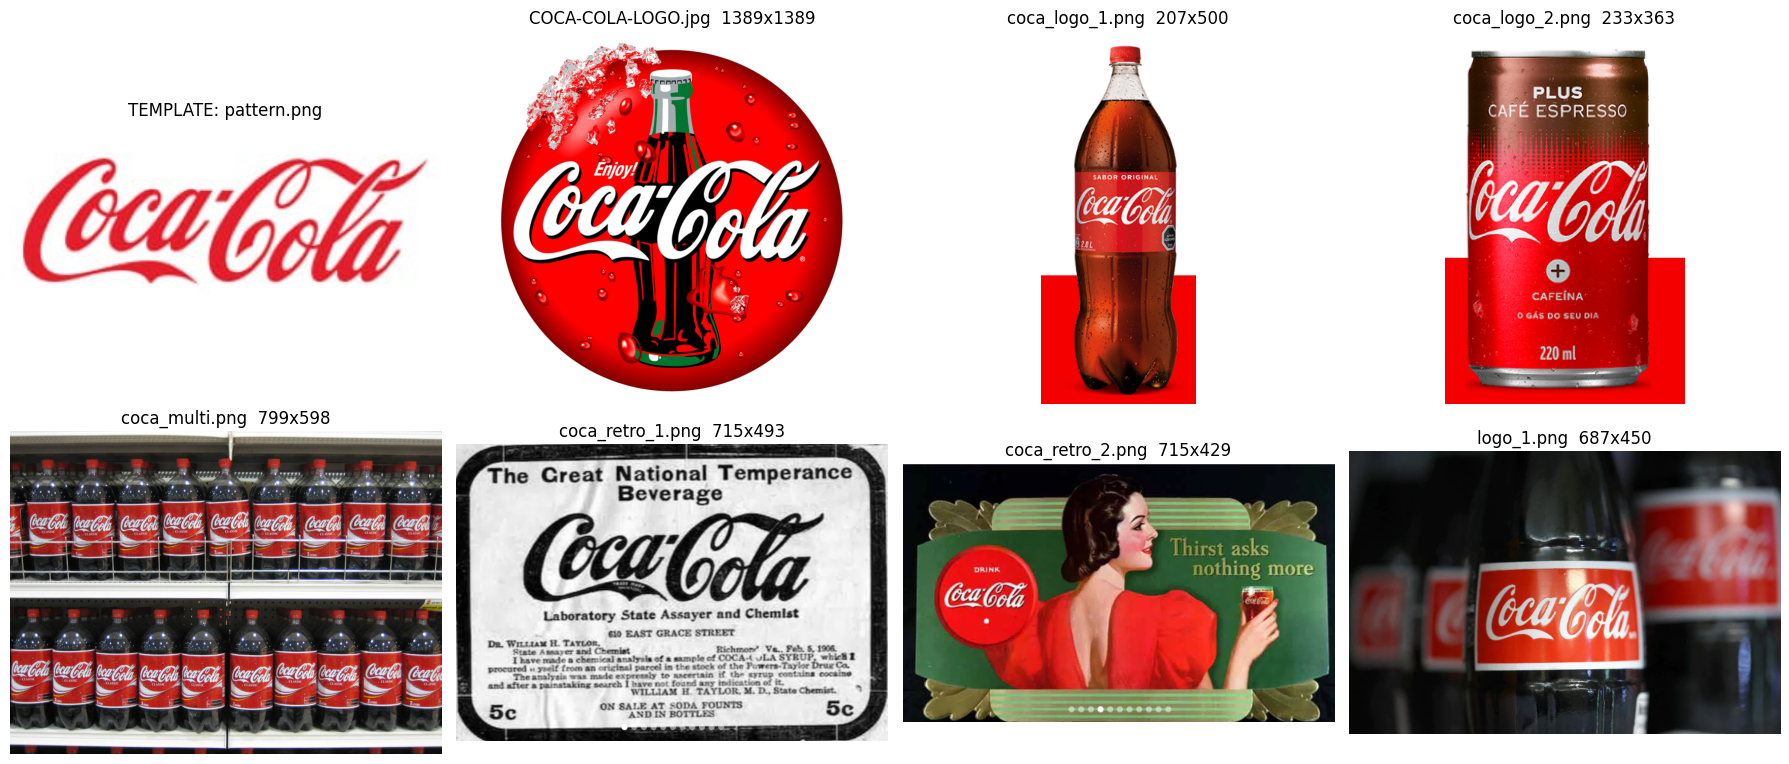

In [ ]:
rutas_imagenes = sorted(glob.glob(os.path.join(IMAGES_DIR, '*')))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

tpl = cv.imread(TEMPLATE_PATH, cv.IMREAD_UNCHANGED)[:, :, :3]
axes[0].imshow(cv.cvtColor(tpl, cv.COLOR_BGR2RGB))
axes[0].set_title('TEMPLATE: pattern.png')

for ax, ruta in zip(axes[1:], rutas_imagenes):
    img = cv.imread(ruta)
    ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax.set_title(f'{os.path.basename(ruta)}  {img.shape[1]}x{img.shape[0]}')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

El template es el texto "Coca-Cola" en rojo sobre fondo blanco, pero en las imágenes el logo aparece distinto. Lo primero que se nota es la escala: en `COCA-COLA-LOGO.jpg` el logo ocupa casi toda la imagen y en `coca_multi.png` hay 18 logos chiquitos. También cambia la polaridad: en casi todos los productos las letras son blancas sobre rojo, al revés que en el template, y solo en el aviso antiguo (`coca_retro_1.png`) son oscuras sobre fondo claro. Además, en la lata (`coca_logo_2.png`) el logo está cortado por el borde izquierdo, así que el template entero no entra en ninguna posición.

Con todo esto, un `cv.matchTemplate` a una sola escala no funciona. Lo resolvimos en dos pasos:

1. Primero estimamos de qué tamaño es el logo y si está invertido o no. Para eso usamos SIFT y una homografía con RANSAC (clase 5), probando con el template normal y con el invertido. Solo la versión con la polaridad correcta da *inliers*, y la homografía nos da el tamaño del logo. Si SIFT no encuentra suficientes inliers, probamos el template a muchas escalas con `cv.resize` (como en `04.Piramides.ipynb`), en las dos polaridades, y nos quedamos con la que mejor correlaciona.
2. Con eso, buscamos el logo con template matching (`TM_CCOEFF_NORMED`) en escalas parecidas a la estimada. Como confianza de cada detección usamos el valor de la correlación.

Sobre el template matching hicimos algunos ajustes más. Trabajamos sobre el canal verde en lugar de la escala de grises, porque ahí el rojo queda casi negro y el blanco casi blanco, y recortamos el template para sacarle los márgenes blancos, que en las fotos no están. Para la lata agregamos un borde reflejado a la imagen, así el logo puede quedar parcialmente afuera, pero pedimos que al menos el 80% de su área esté dentro de la foto. Por último, descartamos las ventanas casi sin textura, porque ahí `TM_CCOEFF_NORMED` divide por una varianza casi nula y da valores altos que no significan nada.

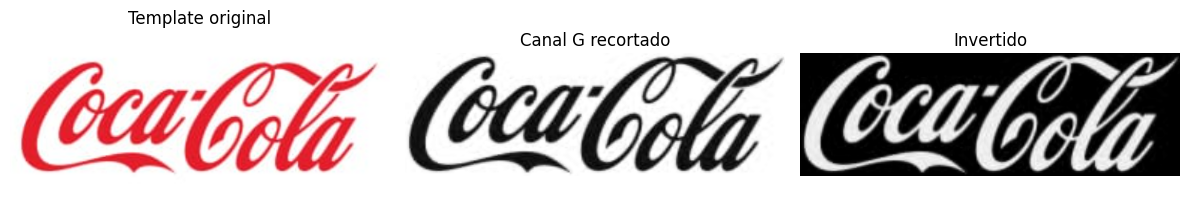

In [ ]:
def cargar_template(path):
    tpl_bgr = cv.imread(path, cv.IMREAD_UNCHANGED)[:, :, :3]
    tpl_g = tpl_bgr[:, :, 1]  # canal verde: maximo contraste rojo/blanco
    # Mascara binaria del texto (Otsu) para recortar el template al texto
    _, tpl_mask = cv.threshold(tpl_g, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
    ys, xs = np.where(tpl_mask > 0)
    pad = 4
    y0, y1 = max(0, ys.min() - pad), ys.max() + pad + 1
    x0, x1 = max(0, xs.min() - pad), xs.max() + pad + 1
    return tpl_bgr, tpl_g, (x0, y0, x1, y1)

tpl_bgr, tpl_g, (X0, Y0, X1, Y1) = cargar_template(TEMPLATE_PATH)
tpl_recorte = tpl_g[Y0:Y1, X0:X1]
TH, TW = tpl_recorte.shape
TPL = {'normal': tpl_recorte.astype(np.float32),
       'invertido': (255 - tpl_recorte).astype(np.float32)}

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(cv.cvtColor(tpl_bgr, cv.COLOR_BGR2RGB)); axes[0].set_title('Template original'); axes[0].axis('off')
axes[1].imshow(TPL['normal'], cmap='gray'); axes[1].set_title('Canal G recortado'); axes[1].axis('off')
axes[2].imshow(TPL['invertido'], cmap='gray'); axes[2].set_title('Invertido'); axes[2].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def canal(img_bgr):
    return cv.GaussianBlur(img_bgr[:, :, 1], (3, 3), 0)


def mapa_desvio_local(img, win_w, win_h):
    # Desvio estandar local (misma resolucion de salida que cv.matchTemplate)
    f = img.astype(np.float32)
    mean = cv.boxFilter(f, -1, (win_w, win_h), normalize=True, borderType=cv.BORDER_ISOLATED)
    mean_sq = cv.boxFilter(f * f, -1, (win_w, win_h), normalize=True, borderType=cv.BORDER_ISOLATED)
    std = np.sqrt(np.clip(mean_sq - mean * mean, 0, None))
    h, w = img.shape
    oh, ow = h - win_h + 1, w - win_w + 1
    return std[win_h // 2: win_h // 2 + oh, win_w // 2: win_w // 2 + ow]


def mapa_ncc(gray, pol, rw, rh, pad_frac=0.15, cobertura_min=0.8, desvio_min=12):
    # Correlacion del template (polaridad 'pol', tamano rw x rh) sobre la imagen.
    # Devuelve el mapa y el padding usado para volver a coordenadas de la imagen.
    ih, iw = gray.shape
    px, py = int(iw * pad_frac), int(ih * pad_frac)
    P = cv.copyMakeBorder(gray, py, py, px, px, cv.BORDER_REFLECT)
    if rw > P.shape[1] or rh > P.shape[0]:
        return None, px, py
    interp = cv.INTER_AREA if rw < TW else cv.INTER_LINEAR
    t = cv.resize(TPL[pol], (rw, rh), interpolation=interp)
    res = cv.matchTemplate(P.astype(np.float32), t, cv.TM_CCOEFF_NORMED)
    res[~np.isfinite(res)] = 0
    res[mapa_desvio_local(P, rw, rh) < desvio_min] = 0  # invalidar zonas planas
    # Exigir que al menos el 80% del logo quede dentro de la imagen original
    H, W = res.shape
    xx, yy = np.arange(W) - px, np.arange(H) - py
    fx = (np.minimum(xx + rw, iw) - np.maximum(xx, 0)).clip(0) / rw
    fy = (np.minimum(yy + rh, ih) - np.maximum(yy, 0)).clip(0) / rh
    res[np.outer(fy, fx) < cobertura_min] = 0
    return res, px, py


sift = cv.SIFT_create()
SIFT_TPL = {pol: sift.detectAndCompute(t, None)
            for pol, t in (('normal', tpl_g), ('invertido', 255 - tpl_g))}


def estimar_sift(img_bgr, min_inliers=12):
    # Escala y polaridad a partir de una homografia SIFT + RANSAC
    g = img_bgr[:, :, 1]
    esc = 1.0
    if max(g.shape) < 600:  # sobremuestrear imagenes chicas para tener mas keypoints
        esc = 600 / max(g.shape)
        g = cv.resize(g, None, fx=esc, fy=esc, interpolation=cv.INTER_CUBIC)
    kp2, des2 = sift.detectAndCompute(g, None)
    if des2 is None:
        return None
    bf = cv.BFMatcher(cv.NORM_L2)
    mejor = None
    for pol, (kp1, des1) in SIFT_TPL.items():
        good = [m for m, n in bf.knnMatch(des1, des2, k=2) if m.distance < 0.75 * n.distance]
        if len(good) < 6:
            continue
        src = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H, mask = cv.findHomography(src, dst, cv.RANSAC, 5.0)
        if H is None:
            continue
        inliers = int(mask.sum())
        if inliers >= min_inliers and (mejor is None or inliers > mejor['inliers']):
            esq = np.float32([[X0, Y0], [X1, Y0], [X1, Y1], [X0, Y1]]).reshape(-1, 1, 2)
            c = cv.perspectiveTransform(esq, H).reshape(-1, 2) / esc
            rw = int(round(np.mean([np.linalg.norm(c[1] - c[0]), np.linalg.norm(c[2] - c[3])])))
            rh = int(round(np.mean([np.linalg.norm(c[3] - c[0]), np.linalg.norm(c[2] - c[1])])))
            mejor = dict(metodo='SIFT+RANSAC', pol=pol, rw=rw, rh=rh, inliers=inliers)
    return mejor


def busqueda_multiescala(img_bgr, n_escalas=80, ancho_min_tpl=60):
    # Fallback: prueba muchas escalas del template y ambas polaridades
    gray = canal(img_bgr)
    ih, iw = gray.shape
    escala_max = min(iw / TW, ih / TH)
    escala_min = min(ancho_min_tpl / TW, escala_max)
    mejor = None
    for s in np.geomspace(escala_min, escala_max, n_escalas):
        rw, rh = int(round(TW * s)), int(round(TH * s))
        for pol in TPL:
            res, _, _ = mapa_ncc(gray, pol, rw, rh)
            if res is None:
                continue
            val = float(res.max())
            if mejor is None or val > mejor['val']:
                mejor = dict(metodo='TM multiescala', pol=pol, rw=rw, rh=rh, val=val)
    return mejor


def buscar_picos(img_bgr, params, max_picos=1,
                 factores=np.geomspace(0.8, 1.25, 9), aspectos=(1.0, 0.9, 1.1)):
    # Template matching con la polaridad estimada, en escalas cercanas a la estimada.
    # Los aspectos 0.9/1.1 absorben la deformacion del logo en botellas y latas.
    gray = canal(img_bgr)
    cajas, puntajes = [], []
    for f in factores:
        for a in aspectos:
            rw, rh = int(round(params['rw'] * f * a)), int(round(params['rh'] * f))
            if rw < 20 or rh < 8:
                continue
            res, px, py = mapa_ncc(gray, params['pol'], rw, rh)
            if res is None:
                continue
            for _ in range(max_picos):
                _, val, _, (x, y) = cv.minMaxLoc(res)
                if val < 0.25:
                    break
                cajas.append((x - px, y - py, rw, rh))
                puntajes.append(val)
                res[max(0, y - rh // 2): y + rh // 2 + 1, max(0, x - rw // 2): x + rw // 2 + 1] = 0
    return cajas, puntajes


def detectar_logo(img_bgr):
    # Etapa 1: escala y polaridad (SIFT o, si no alcanza, template matching multi-escala)
    params = estimar_sift(img_bgr) or busqueda_multiescala(img_bgr)
    # Etapa 2: template matching refinado; nos quedamos con el mejor pico
    cajas, puntajes = buscar_picos(img_bgr, params)
    i = int(np.argmax(puntajes))
    return params['metodo'], puntajes[i], cajas[i], params


def dibujar(img_bgr, cajas, puntajes, grosor=2, fuente=0.6):
    out = cv.cvtColor(img_bgr.copy(), cv.COLOR_BGR2RGB)
    for (x, y, w, h), p in zip(cajas, puntajes):
        cv.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), grosor)
        cv.putText(out, f'{p:.2f}', (max(0, x), max(15, y - 6)), cv.FONT_HERSHEY_SIMPLEX,
                   fuente, (0, 200, 0), grosor)
    return out

## Ítem 1: una detección por imagen, sin falsos positivos

Corremos el detector sobre las 7 imágenes de `images/` y nos quedamos, para cada una, con la caja de mayor confianza.

In [ ]:
rutas_imagenes = sorted(glob.glob(os.path.join(IMAGES_DIR, '*')))
print(f'{len(rutas_imagenes)} imagenes encontradas:')
for r in rutas_imagenes:
    print(' -', os.path.basename(r))

7 imagenes encontradas:
 - COCA-COLA-LOGO.jpg
 - coca_logo_1.png
 - coca_logo_2.png
 - coca_multi.png
 - coca_retro_1.png
 - coca_retro_2.png
 - logo_1.png


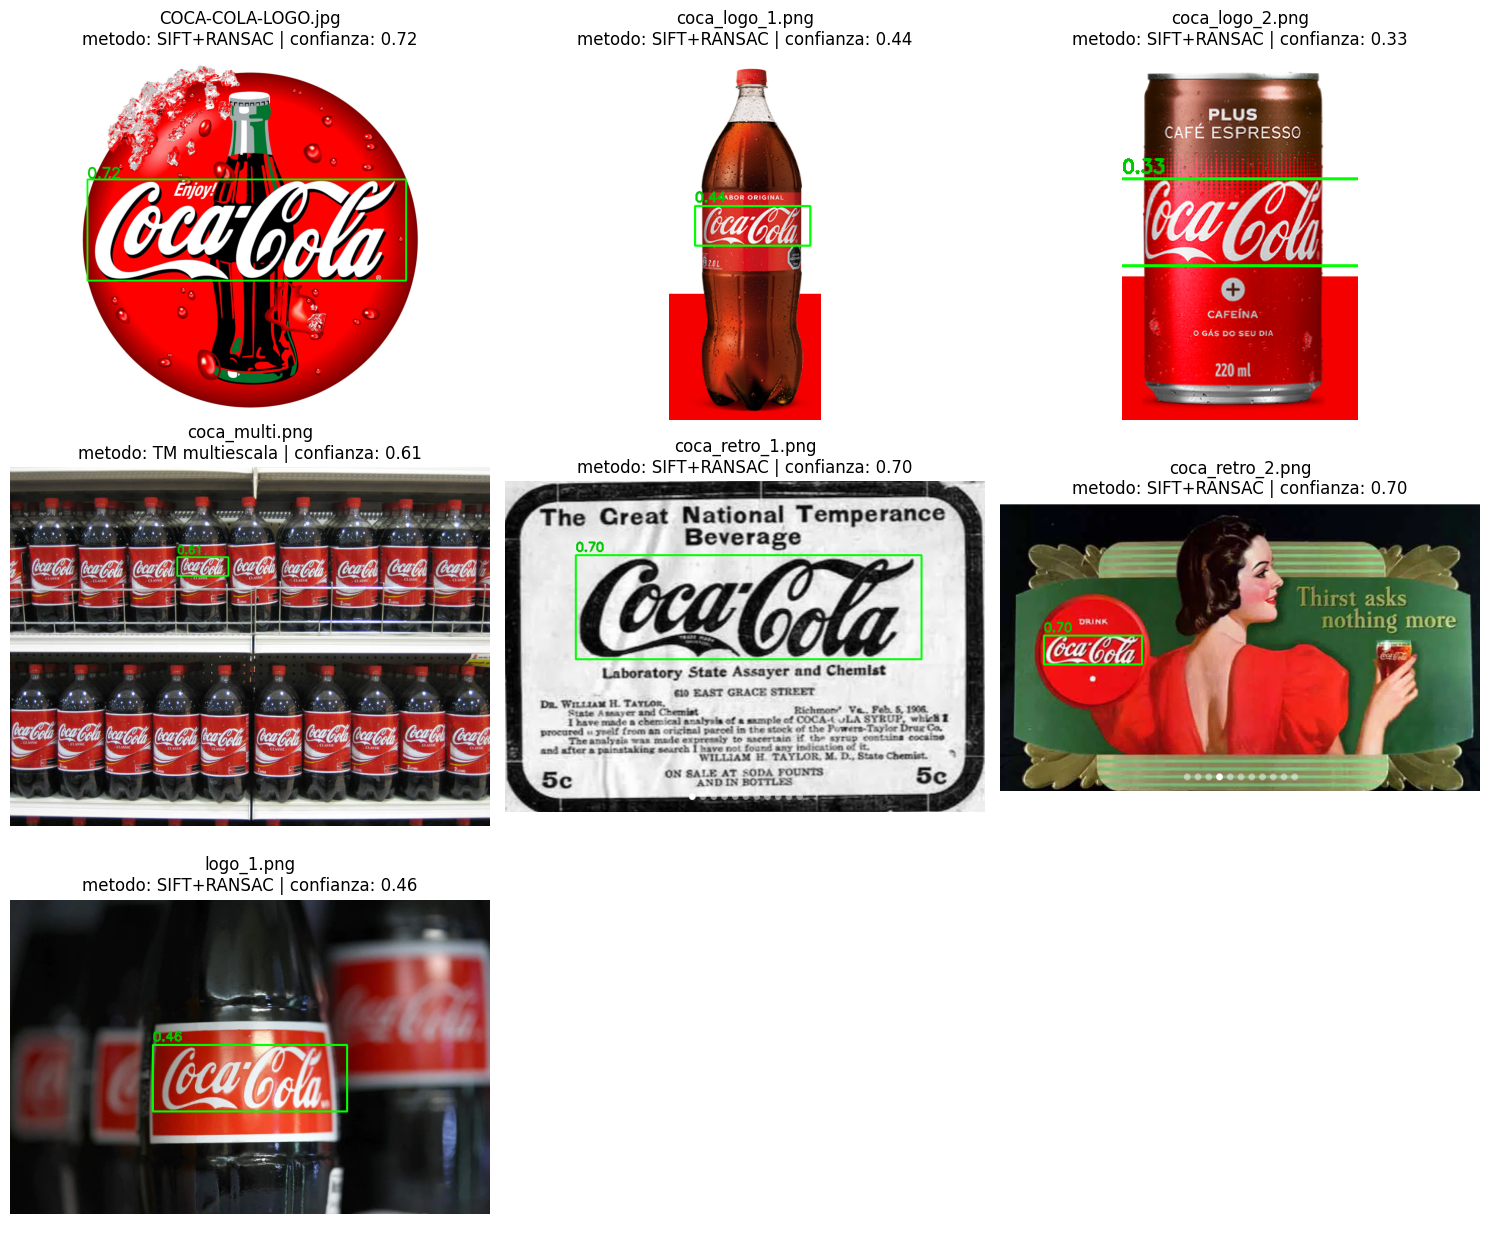

COCA-COLA-LOGO.jpg     -> metodo=SIFT+RANSAC     polaridad=invertido  confianza=0.717  bbox=(77, 478, 1206, 383)
coca_logo_1.png        -> metodo=SIFT+RANSAC     polaridad=invertido  confianza=0.435  bbox=(35, 208, 157, 54)
coca_logo_2.png        -> metodo=SIFT+RANSAC     polaridad=invertido  confianza=0.329  bbox=(-16, 124, 250, 86)
coca_multi.png         -> metodo=TM multiescala  polaridad=invertido  confianza=0.613  bbox=(278, 151, 85, 31)
coca_retro_1.png       -> metodo=SIFT+RANSAC     polaridad=normal     confianza=0.700  bbox=(105, 110, 515, 155)
coca_retro_2.png       -> metodo=SIFT+RANSAC     polaridad=invertido  confianza=0.699  bbox=(65, 197, 146, 43)
logo_1.png             -> metodo=SIFT+RANSAC     polaridad=invertido  confianza=0.463  bbox=(204, 208, 278, 95)


In [ ]:
resultados_item1 = {}

n = len(rutas_imagenes)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4.2*rows))
axes = np.array(axes).reshape(-1)

for i, ruta in enumerate(rutas_imagenes):
    nombre = os.path.basename(ruta)
    img = cv.imread(ruta)
    metodo, val, box, params = detectar_logo(img)
    resultados_item1[nombre] = (metodo, val, box, params)

    escala_txt = max(1, img.shape[1] // 400)
    axes[i].imshow(dibujar(img, [box], [val], grosor=2 * escala_txt, fuente=0.6 * escala_txt))
    axes[i].set_title(f'{nombre}\nmetodo: {metodo} | confianza: {val:.2f}')
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

for nombre, (metodo, val, box, params) in resultados_item1.items():
    print(f"{nombre:22s} -> metodo={metodo:15s} polaridad={params['pol']:10s} confianza={val:.3f}  bbox={box}")

### Resultados

El logo se encuentra bien en las 7 imágenes y no hay falsos positivos.

La lata fue la imagen que más trabajo nos dio. Como el logo está cortado por el borde izquierdo, la caja empieza en x negativo y se dibuja recortada. Sin el borde reflejado no la detectábamos, y sin SIFT el template matching terminaba eligiendo el texto "PLUS CAFÉ ESPRESSO", que también es blanco sobre rojo.

En `coca_retro_1.png` gana el template normal, porque es la única imagen con letras oscuras sobre fondo claro. En el resto gana el invertido. Y `coca_multi.png` es la única en la que SIFT no alcanza y se usa el template matching multi-escala.

La confianza cambia mucho de una imagen a otra: va de 0.33 en la lata a 0.72 en el logo gráfico, según cuánto se parezca cada logo a la tipografía del template.

## Ítem 2: detecciones múltiples en `coca_multi.png`

Con el mismo template, en lugar de quedarnos con el máximo de la correlación, buscamos todos los picos en escalas cercanas a la estimada. Como alrededor de cada logo aparecen muchas ventanas parecidas, aplicamos Non-Maximum Suppression (NMS) para dejar una sola por logo. Al final conservamos las detecciones con una confianza de al menos 0.70 veces la de la mejor.

In [ ]:
def nms(cajas, puntajes, iou_umbral=0.3):
    idxs = np.argsort(puntajes)[::-1]
    cajas = np.array(cajas, dtype=np.float32)
    conservar = []
    while len(idxs) > 0:
        i = idxs[0]
        conservar.append(i)
        if len(idxs) == 1:
            break
        resto = idxs[1:]
        xx1 = np.maximum(cajas[i, 0], cajas[resto, 0])
        yy1 = np.maximum(cajas[i, 1], cajas[resto, 1])
        xx2 = np.minimum(cajas[i, 0]+cajas[i, 2], cajas[resto, 0]+cajas[resto, 2])
        yy2 = np.minimum(cajas[i, 1]+cajas[i, 3], cajas[resto, 1]+cajas[resto, 3])
        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)
        inter = w * h
        area_i = cajas[i, 2] * cajas[i, 3]
        area_r = cajas[resto, 2] * cajas[resto, 3]
        iou = inter / (area_i + area_r - inter + 1e-6)
        idxs = resto[iou < iou_umbral]
    return conservar


def detectar_multiples(img_bgr, params, umbral_rel=0.70, iou_umbral=0.3):
    # Extrae todos los picos (con la escala y polaridad del item 1), aplica NMS
    # y conserva los que superan umbral_rel * confianza del mejor.
    cajas, puntajes = buscar_picos(img_bgr, params, max_picos=60)
    idxs = nms(cajas, puntajes, iou_umbral=iou_umbral)
    mejor = max(puntajes[i] for i in idxs)
    idxs = [i for i in idxs if puntajes[i] >= umbral_rel * mejor]
    return [cajas[i] for i in idxs], [puntajes[i] for i in idxs]

Detecciones tras NMS: 18


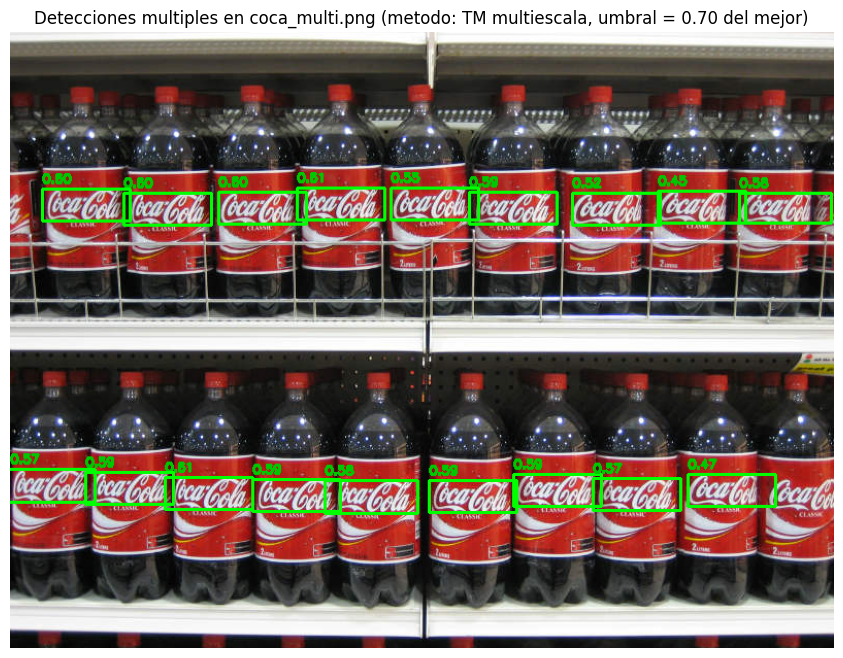

In [ ]:
ruta_multi = os.path.join(IMAGES_DIR, 'coca_multi.png')
img_multi = cv.imread(ruta_multi)
metodo, val, box, params = resultados_item1['coca_multi.png']

cajas, puntajes = detectar_multiples(img_multi, params)
print(f'Detecciones tras NMS: {len(cajas)}')

plt.figure(figsize=(11, 8))
plt.imshow(dibujar(img_multi, cajas, puntajes, grosor=2, fuente=0.4))
plt.title(f'Detecciones multiples en coca_multi.png (metodo: {metodo}, umbral = 0.70 del mejor)')
plt.axis('off')
plt.show()

Para validar el resultado contamos los logos a mano: hay 18 completos (9 por estante) y 3 cortados por los bordes de la foto. El algoritmo encuentra los 18 completos, cada caja sobre un logo distinto, y no marca nada que no sea un logo.

#### Logos cortados por el borde

Los 3 logos cortados no se detectan, y es a propósito. Dos son los de los extremos del estante de arriba: del de la izquierda solo se ve "ola" y del de la derecha apenas el principio. El tercero, abajo a la derecha, es el más visible (se lee "Coca-Col").

El borde reflejado que agregamos para la lata es un espejo de la imagen, así que si aceptáramos cualquier coincidencia en esa zona el algoritmo podría encontrar logos que no existen. Por eso exigimos que al menos el 80% del área del logo esté dentro de la foto, y ninguno de estos tres llega.

#### Umbral de confianza

El 0.70 lo elegimos mirando los candidatos de todas las imágenes. En las que tienen un solo logo, el falso candidato más alto llega a 0.67 veces el mejor (en la lata), y en `coca_multi.png` el logo real más débil está en 0.73 veces el mejor. El 0.70 queda entre los dos, aunque el margen es chico.

## Ítem 3: generalizar la detección múltiple a todas las imágenes

Corremos `detectar_multiples` sobre las 7 imágenes, con el mismo umbral de 0.70 y la escala y polaridad que se estimaron en el ítem 1. En las imágenes con un solo logo deberíamos obtener una sola detección, y en `coca_multi.png`, las 18.

COCA-COLA-LOGO.jpg     ->  1 deteccion(es), confianzas=[0.72]
coca_logo_1.png        ->  1 deteccion(es), confianzas=[0.44]
coca_logo_2.png        ->  1 deteccion(es), confianzas=[0.33]
coca_multi.png         -> 18 deteccion(es), confianzas=[0.61, 0.61, 0.6, 0.6, 0.6, 0.59, 0.59, 0.59, 0.59, 0.59, 0.58, 0.58, 0.57, 0.57, 0.55, 0.52, 0.47, 0.45]
coca_retro_1.png       ->  1 deteccion(es), confianzas=[0.7]
coca_retro_2.png       ->  1 deteccion(es), confianzas=[0.7]
logo_1.png             ->  1 deteccion(es), confianzas=[0.46]


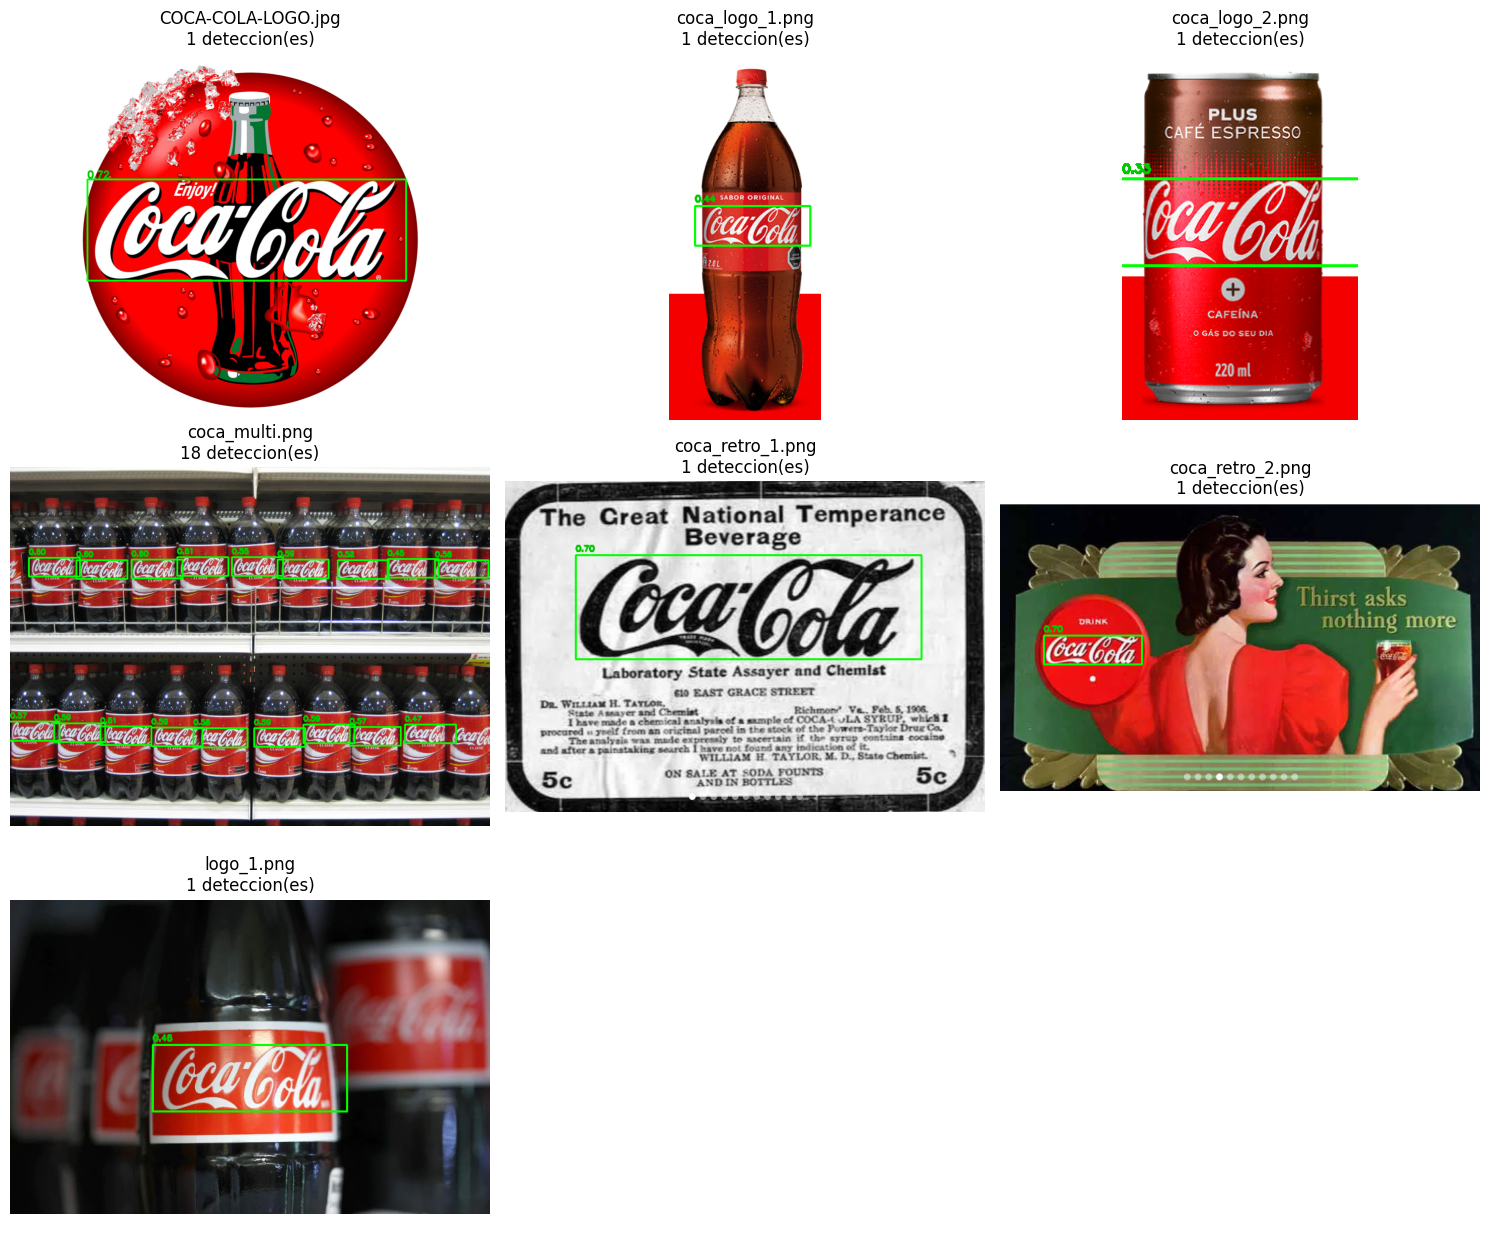

In [ ]:
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4.2*rows))
axes = np.array(axes).reshape(-1)

for i, ruta in enumerate(rutas_imagenes):
    nombre = os.path.basename(ruta)
    img = cv.imread(ruta)
    metodo, val, box, params = resultados_item1[nombre]
    cajas, puntajes = detectar_multiples(img, params)

    escala_txt = max(1, img.shape[1] // 400)
    axes[i].imshow(dibujar(img, cajas, puntajes, grosor=2 * escala_txt, fuente=0.4 * escala_txt))
    axes[i].set_title(f'{nombre}\n{len(cajas)} deteccion(es)')
    axes[i].axis('off')
    print(f'{nombre:22s} -> {len(cajas):2d} deteccion(es), confianzas={[round(p, 2) for p in puntajes]}')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

En las imágenes con un solo logo queda una única detección, porque el NMS junta las ventanas que caen sobre el mismo logo y el umbral descarta el resto. En `coca_multi.png` quedan las 18. No aparece ningún falso positivo.

Lo que sí se pierde son algunos logos reales. En `logo_1.png`, los de las botellas desenfocadas del fondo: el desenfoque borra justo el detalle que usa la correlación, y quedan con una confianza de alrededor de 0.2 (por debajo de varios candidatos falsos). En `coca_retro_2.png`, el logo chiquito del vaso: está a una escala muy distinta a la del logo principal y el detector solo busca cerca de esa escala. Probamos buscar en todas las escalas, pero con templates tan chicos aparecen muchos falsos positivos en las otras imágenes.

## Conclusiones

En el ítem 1 encontramos el logo en las 7 imágenes sin falsos positivos. El caso más difícil fue la lata, con el logo cortado por el borde y otro texto blanco sobre rojo que competía con él. En el ítem 2 se detectan los 18 logos completos de `coca_multi.png`, sin falsos positivos según nuestro conteo a mano. Los 3 cortados quedan afuera por el criterio del 80% del área. En el ítem 3, el mismo algoritmo sin cambiar parámetros da una detección por imagen en las de un solo logo y 18 en la góndola. Lo que no logramos detectar son los logos desenfocados de `logo_1.png` y el del vaso en `coca_retro_2.png`.

Lo principal que nos llevamos es que el template matching solo es muy sensible a la escala y a la polaridad. Al probar muchas escalas, los templates chicos correlacionan bien con cualquier texto o textura y el algoritmo termina eligiendo cualquier cosa. La solución fue combinarlo con SIFT que estima la escala y la polaridad cuando hay un logo grande, y el template matching se encarga de ubicarlo y de encontrar logos repetidos. El borde reflejado y el descarte de zonas planas resolvieron problemas más puntuales, como la lata y los picos falsos en fondos lisos.

## Posibles mejoras

- El umbral de 0.70 lo ajustamos con las mismas imágenes que evaluamos, y la validación del ítem 2 fue contando a mano sobre una sola imagen. Con más imágenes anotadas podríamos elegir el umbral con datos aparte y calcular precisión y recall.
- Para detectar logos de distintos tamaños en una misma imagen, como el del vaso, se podría normalizar el puntaje de cada escala o verificar aparte los candidatos chicos.
- Para los logos desenfocados se podría probar con versiones del template suavizadas con un filtro gaussiano.
- En la góndola, SIFT podría funcionar repitiendo RANSAC y sacando los inliers de cada logo encontrado, con un filtrado de matches que no descarte los patrones repetidos.